Run this once if your environment is missing packages.

In [1]:
%pip install -q pandas numpy scikit-learn xgboost lightgbm catboost matplotlib optuna


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: /Users/rusli/Documents/GitHub/Rice-To-Meet-You/.venv/bin/python3.14 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
# Optional: preview the prebuilt feature table if your local pyarrow version can read it.
# The model demo below does not depend on this parquet file; it reads the CSV directly.
import pandas as pd

features_path = "data/features.parquet"
try:
    print(f"Loading optional feature data from {features_path}")
    features_preview = pd.read_parquet(features_path)
    print(f"Loaded {len(features_preview)} rows with columns: {list(features_preview.columns)}")
    display(features_preview.head())
except Exception as exc:
    print(f"Skipping optional parquet preview: {exc}")
    print("Continue to the next cell; the model workflow uses the CSV file directly.")


Loading optional feature data from data/features.parquet
Skipping optional parquet preview: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.
Continue to the next cell; the model workflow uses the CSV file directly.


## Heat-index forecasting: model testing workflow

The target is **tomorrow's heat index**, predicted from today's weather. The previous version predicted the *same-day* heat index, which is computed directly from temperature and humidity — so models were just reverse-engineering a known formula. Forecasting is a real prediction task.

1. **Load & hygiene** — combine CSV exports; drop exact duplicate rows from overlapping exports (reported), fail fast on conflicting rows; check gaps and NaNs.
2. **Features & split** — today's weather + heat-index lags/rolling means + seasonality; chronological train/test split; persistence baseline.
3. **Model comparison** — leakage-free CV: scaling lives inside a `Pipeline`, folds are expanding time windows (`TimeSeriesSplit`), scored on RMSE/MAE/R².
4. **Hyperparameter tuning** — an Optuna study (TPE sampler) per model, so the comparison isn't just "whose defaults fit best".
5. **Held-out evaluation** — the most recent ~20% of days, touched exactly once, with diagnostic plots.
6. **Permutation importance** — which features the final model actually uses.

### 1 · Load & data hygiene

In [3]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_validate, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

# Optional boosting libraries that may not be installed/loadable in every environment.
try:
    import xgboost as xgb
    xgboost_available = True
except Exception as exc:
    xgboost_available = False
    print("Warning: XGBoost not available in this environment. Skipping XGBoost model.")
    print(str(exc))
    print("On Mac, you may need to install libomp: brew install libomp")

try:
    import lightgbm as lgb
    lightgbm_available = True
except Exception as exc:
    lightgbm_available = False
    print("Warning: LightGBM not available in this environment. Skipping LightGBM model.")
    print(str(exc))

try:
    import catboost as cb
    catboost_available = True
except Exception as exc:
    catboost_available = False
    print("Warning: CatBoost not available in this environment. Skipping CatBoost model.")
    print(str(exc))

city_filter = "KQRH"  # change this to the desired city's ICAO identifier
random_state = 42

# Load and combine all matching daily weather CSV files.
csv_paths = sorted(Path("data").glob("daily-weather-rice_*.csv"))
if not csv_paths:
    raise FileNotFoundError("No CSV files found matching data/daily-weather-rice_*.csv")
df_raw = pd.concat((pd.read_csv(path) for path in csv_paths), ignore_index=True)
print(f"Loaded {len(df_raw)} rows from {len(csv_paths)} CSV files")

# Overlapping exports happen (a re-downloaded or copied file); exact duplicate rows
# carry no information and would inflate every CV score, so drop them and say so.
dup_rows = int(df_raw.duplicated().sum())
if dup_rows:
    df_raw = df_raw.drop_duplicates(ignore_index=True)
    print(f"Dropped {dup_rows} exact duplicate rows from overlapping exports ({len(df_raw)} remain)")

# Conflicting rows - same city and date but different measurements - can't be
# auto-resolved, so those still fail fast.
key_cols = ["CITY_LOCATION_IDENTIFIER__UP_TO_9_ALPHANUMERIC_CHARACTERS_", "VALID_DATE_AS_YYYYMMDD"]
conflicts = int(df_raw.duplicated(subset=key_cols).sum())
assert conflicts == 0, f"{conflicts} conflicting rows (same city+date, different values) - resolve before modeling"

# Normalize raw columns into the units the model expects.
df = pd.DataFrame({
    "city": df_raw["CITY_LOCATION_IDENTIFIER__UP_TO_9_ALPHANUMERIC_CHARACTERS_"],
    "date": pd.to_datetime(df_raw["VALID_DATE_AS_YYYYMMDD"]),
    "temp_f": df_raw["AVERAGE_TEMPERATURE_C___FLOAT_VALUE_TO_NEAREST_HUNDREDTHS_PLACE"] * 9 / 5 + 32,
    "temp_max_f": df_raw["MAXIMUM_TEMPERATURE_C___FLOAT_VALUE_TO_NEAREST_HUNDREDTHS_PLACE"] * 9 / 5 + 32,
    "temp_min_f": df_raw["MINIMUM_TEMPERATURE_C___FLOAT_VALUE_TO_NEAREST_HUNDREDTHS_PLACE"] * 9 / 5 + 32,
    "humidity": df_raw["AVERAGE_RELATIVE_HUMIDITY_____FLOAT_VALUE_TO_NEAREST_HUNDREDTHS_PLACE"],
    # header says F but the values track degrees C; the models only need it to be consistent
    "dew_point": df_raw["AVERAGE_DEW_POINT_F___FLOAT_VALUE_TO_NEAREST_HUNDREDTHS_PLACE"],
    "pressure_mb": df_raw["AVERAGE_SEA_LEVEL_PRESSURE_MILLIBARS___FLOAT_VALUE_TO_NEAREST_HUNDREDTHS_PLACE"],
    "visibility_km": df_raw["AVERAGE_VISIBILITY_KILOMETERS___FLOAT_VALUE_TO_NEAREST_HUNDREDTHS_PLACE"],
    "wind_mph": df_raw["AVERAGE_WIND_SPEED_KNOTS___FLOAT_VALUE_TO_NEAREST_HUNDREDTHS_PLACE"] * 1.15078,
    # -1 means no precipitation, 0 means trace; stored in hundredths of a millimeter
    "precip_mm": df_raw["PRECIPITATION_INTEGER_IN_HUNDREDTHS_OF_A_MILLIMETER___LIQUID_EQUIVALENT____0__IS_USED_FOR_TRACE_AMOUNTS_AND___1__IS_USED_FOR_NO_PRECIPITATION"].clip(lower=0) / 100,
})

city_df = df[df["city"] == city_filter].drop(columns="city").sort_values("date").reset_index(drop=True)
if city_df.empty:
    raise ValueError(f"No rows found for city {city_filter}")

span_days = (city_df["date"].max() - city_df["date"].min()).days + 1
print(f"{city_filter}: {len(city_df)} daily rows, {city_df['date'].min().date()} to {city_df['date'].max().date()} "
      f"({span_days - len(city_df)} missing days)")
print(f"NaN cells: {int(city_df.isna().sum().sum())}")


Loaded 712714 rows from 30 CSV files


KQRH: 1790 daily rows, 2020-01-01 to 2024-12-31 (37 missing days)
NaN cells: 0


### 2 · Forecasting features & chronological split

Features are **today's** weather (all columns the CSVs provide, not just three), recent heat-index history (lags and rolling means), and day-of-year seasonality. Lags are computed on a daily-continuous index so a gap in the record produces a dropped row rather than silently lagging across it. The split is **chronological** — shuffling would let models train on days that come after the ones they're tested on. The **persistence baseline** (tomorrow = today) is the number every model must beat to have learned anything.

In [4]:
# NWS heat index: Steadman's simple formula everywhere, refined with the Rothfusz
# regression where it reads >= 80F. Valid across the whole year, unlike Rothfusz
# alone, which is only defined for hot days.
def heat_index_f(temp_f, humidity):
    t = np.asarray(temp_f, dtype=float)
    rh = np.asarray(humidity, dtype=float)
    hi = 0.5 * (t + 61.0 + (t - 68.0) * 1.2 + rh * 0.094)
    hot = hi >= 80
    th, rhh = t[hot], rh[hot]
    hi[hot] = (
        -42.379 + 2.04901523 * th + 10.14333127 * rhh - 0.22475541 * th * rhh
        - 0.00683783 * th**2 - 0.05481717 * rhh**2 + 0.00122874 * th**2 * rhh
        + 0.00085282 * th * rhh**2 - 0.00000199 * th**2 * rhh**2
    )
    return hi

# Daily-continuous index: the missing days come back as NaN rows, so shifts and
# rolling windows produce NaN next to a gap (dropped below) instead of silently
# lagging across it.
daily = city_df.set_index("date").asfreq("D")
daily["heat_index"] = heat_index_f(daily["temp_f"], daily["humidity"])

for lag in (1, 2, 3):
    daily[f"hi_lag{lag}"] = daily["heat_index"].shift(lag)
for window in (3, 7):
    daily[f"hi_roll{window}"] = daily["heat_index"].rolling(window).mean()

# Seasonality as a continuous circular signal.
day_of_year = daily.index.dayofyear
daily["doy_sin"] = np.sin(2 * np.pi * day_of_year / 365.25)
daily["doy_cos"] = np.cos(2 * np.pi * day_of_year / 365.25)

# The target is TOMORROW's heat index - something today's formula cannot compute.
daily["hi_next_day"] = daily["heat_index"].shift(-1)

feature_cols = ["temp_f", "temp_max_f", "temp_min_f", "humidity", "dew_point", "pressure_mb",
                "visibility_km", "wind_mph", "precip_mm", "heat_index",
                "hi_lag1", "hi_lag2", "hi_lag3", "hi_roll3", "hi_roll7", "doy_sin", "doy_cos"]
target_col = "hi_next_day"

data = daily[feature_cols + [target_col]].dropna()
print(f"{len(data)} usable day -> next-day samples after dropping gap-adjacent rows")

# Chronological split: the most recent ~20% of days are held out and touched once, at the end.
split_at = int(len(data) * 0.8)
train, test = data.iloc[:split_at], data.iloc[split_at:]
X_train, y_train = train[feature_cols], train[target_col]
X_test, y_test = test[feature_cols], test[target_col]
print(f"train: {len(train)} days ({train.index.min().date()} to {train.index.max().date()})")
print(f"test:  {len(test)} days ({test.index.min().date()} to {test.index.max().date()})")

def report_scores(label, y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    print(f"{label}: RMSE={rmse:.3f}  MAE={mean_absolute_error(y_true, y_pred):.3f}  "
          f"R2={r2_score(y_true, y_pred):.3f}")
    return rmse

# Persistence baseline (tomorrow = today): the score every model has to beat.
_ = report_scores("Persistence baseline (train)", y_train, X_train["heat_index"])
_ = report_scores("Persistence baseline (test) ", y_test, X_test["heat_index"])


1550 usable day -> next-day samples after dropping gap-adjacent rows
train: 1240 days (2020-01-07 to 2023-10-16)
test:  310 days (2023-10-17 to 2024-12-30)
Persistence baseline (train): RMSE=4.434  MAE=3.251  R2=0.861
Persistence baseline (test) : RMSE=4.494  MAE=3.230  R2=0.839


### 3 · Model comparison — leakage-free time-series CV

Two leakage fixes over the previous version: the scaler is fit **inside** each CV fold (via `Pipeline`) instead of once on the full dataset, and cross-validation runs on the **training window only**, so the held-out test days can't influence model selection. `cross_validate` scores RMSE, MAE and R² in a single fit per fold.

In [5]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=random_state),
    "Lasso Regression": Lasso(random_state=random_state, max_iter=50000),
    "Elastic Net": ElasticNet(random_state=random_state, max_iter=50000),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=random_state),
    "Gradient Boosting": GradientBoostingRegressor(random_state=random_state),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=random_state),
    "Support Vector Regression": SVR(),
    "Neural Network (MLP)": MLPRegressor(random_state=random_state, max_iter=5000, early_stopping=True),
}
if xgboost_available:
    models["XGBoost"] = xgb.XGBRegressor(objective="reg:squarederror", random_state=random_state,
                                         n_jobs=1, verbosity=0)
if lightgbm_available:
    models["LightGBM"] = lgb.LGBMRegressor(random_state=random_state, verbose=-1, n_jobs=1)
if catboost_available:
    # allow_writing_files=False stops CatBoost from dumping catboost_info/ logs next to the notebook
    models["CatBoost"] = cb.CatBoostRegressor(random_state=random_state, verbose=False,
                                              thread_count=1, allow_writing_files=False)

# Linear/distance/gradient models need standardized features; tree ensembles split on
# raw thresholds and don't.
scaled_models = {"Linear Regression", "Ridge Regression", "Lasso Regression", "Elastic Net",
                 "Support Vector Regression", "Neural Network (MLP)"}

def as_pipeline(name, estimator):
    # The scaler lives inside the pipeline, so CV re-fits it on each fold's training
    # window only - scaling the full dataset up front leaks test-fold statistics.
    steps = ([("scaler", StandardScaler())] if name in scaled_models else []) + [("model", estimator)]
    return Pipeline(steps)

# Expanding forward windows: every fold trains strictly on the past. Repeated shuffled
# k-fold is invalid for a forecast (it trains on the future); 8 forward folds instead
# give enough per-fold scores to judge whether ranking gaps exceed fold noise (the +/-).
tscv = TimeSeriesSplit(n_splits=8)
scoring = {"rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error", "r2": "r2"}

cv_rows = []
for name, model in models.items():
    scores = cross_validate(as_pipeline(name, clone(model)), X_train, y_train, cv=tscv, scoring=scoring)
    cv_rows.append({
        "model": name,
        "cv_rmse_mean": -scores["test_rmse"].mean(),
        "cv_rmse_std": scores["test_rmse"].std(),
        "cv_mae_mean": -scores["test_mae"].mean(),
        "cv_r2_mean": scores["test_r2"].mean(),
    })
    r = cv_rows[-1]
    print(f"{name}: RMSE={r['cv_rmse_mean']:.3f} (+/-{r['cv_rmse_std']:.3f})  "
          f"MAE={r['cv_mae_mean']:.3f}  R2={r['cv_r2_mean']:.3f}")

persistence_rmse = np.array([
    mean_squared_error(y_train.iloc[test_idx], X_train["heat_index"].iloc[test_idx]) ** 0.5
    for _, test_idx in tscv.split(X_train)
])
print(f"Persistence baseline: RMSE={persistence_rmse.mean():.3f} (+/-{persistence_rmse.std():.3f})")

cv_results_df = pd.DataFrame(cv_rows).sort_values("cv_rmse_mean").reset_index(drop=True)
print("\nDefault-hyperparameter comparison (8 forward folds):")
print(cv_results_df.round(3).to_string(index=False))


Linear Regression: RMSE=4.148 (+/-0.990)  MAE=3.217  R2=0.664
Ridge Regression: RMSE=4.110 (+/-0.924)  MAE=3.185  R2=0.672
Lasso Regression: RMSE=4.417 (+/-1.026)  MAE=3.432  R2=0.621
Elastic Net: RMSE=4.323 (+/-0.990)  MAE=3.299  R2=0.647


Random Forest: RMSE=5.018 (+/-1.286)  MAE=3.858  R2=0.412


Gradient Boosting: RMSE=4.860 (+/-1.385)  MAE=3.753  R2=0.492


Hist Gradient Boosting: RMSE=4.919 (+/-0.997)  MAE=3.780  R2=0.487
Support Vector Regression: RMSE=5.842 (+/-3.280)  MAE=4.576  R2=0.071


Neural Network (MLP): RMSE=16.782 (+/-18.899)  MAE=12.522  R2=-18.815


XGBoost: RMSE=5.407 (+/-1.484)  MAE=4.165  R2=0.349


LightGBM: RMSE=4.926 (+/-1.082)  MAE=3.778  R2=0.484


CatBoost: RMSE=4.816 (+/-1.841)  MAE=3.658  R2=0.500
Persistence baseline: RMSE=4.509 (+/-1.180)

Default-hyperparameter comparison (8 forward folds):
                    model  cv_rmse_mean  cv_rmse_std  cv_mae_mean  cv_r2_mean
         Ridge Regression         4.110        0.924        3.185       0.672
        Linear Regression         4.148        0.990        3.217       0.664
              Elastic Net         4.323        0.990        3.299       0.647
         Lasso Regression         4.417        1.026        3.432       0.621
                 CatBoost         4.816        1.841        3.658       0.500
        Gradient Boosting         4.860        1.385        3.753       0.492
   Hist Gradient Boosting         4.919        0.997        3.780       0.487
                 LightGBM         4.926        1.082        3.778       0.484
            Random Forest         5.018        1.286        3.858       0.412
                  XGBoost         5.407        1.484        4.165    

### 4 · Hyperparameter tuning (Optuna)

Comparing defaults against defaults mostly measures whose defaults happen to suit this data — Lasso and Elastic Net look bad out of the box largely because their default `alpha=1.0` is far too strong. Each model gets an **Optuna study** (30 trials × 5 forward folds, TPE sampler): the first ~10 trials sample randomly, then the sampler concentrates draws where past trials scored well, so the budget goes further than uniform random search. The objective is the same leakage-free forward-fold RMSE as everywhere else. Linear regression has no knobs, so its plain CV score carries over.

In [6]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)  # one summary line per model, not 30 per trial

# MLP layer layouts behind string keys: Optuna categoricals want plain str/int/float.
mlp_layouts = {"50": (50,), "100": (100,), "100x50": (100, 50), "200": (200,)}

# Each entry maps an Optuna trial to model hyperparameters. suggest_float(log=True)
# plays the role loguniform did for RandomizedSearchCV.
param_suggesters = {
    "Ridge Regression": lambda t: {"alpha": t.suggest_float("alpha", 1e-3, 1e3, log=True)},
    "Lasso Regression": lambda t: {"alpha": t.suggest_float("alpha", 1e-4, 1e1, log=True)},
    "Elastic Net": lambda t: {"alpha": t.suggest_float("alpha", 1e-4, 1e1, log=True),
                              "l1_ratio": t.suggest_float("l1_ratio", 0.05, 0.95)},
    "Random Forest": lambda t: {"n_estimators": t.suggest_int("n_estimators", 100, 500),
                                "max_depth": t.suggest_categorical("max_depth", [None, 5, 10, 20]),
                                "min_samples_leaf": t.suggest_int("min_samples_leaf", 1, 10),
                                "max_features": t.suggest_categorical("max_features", ["sqrt", 0.5, 1.0])},
    "Gradient Boosting": lambda t: {"n_estimators": t.suggest_int("n_estimators", 100, 500),
                                    "learning_rate": t.suggest_float("learning_rate", 0.01, 0.3, log=True),
                                    "max_depth": t.suggest_int("max_depth", 2, 4),
                                    "subsample": t.suggest_float("subsample", 0.6, 1.0)},
    "Hist Gradient Boosting": lambda t: {"learning_rate": t.suggest_float("learning_rate", 0.01, 0.3, log=True),
                                         "max_iter": t.suggest_int("max_iter", 100, 500),
                                         "max_leaf_nodes": t.suggest_categorical("max_leaf_nodes", [15, 31, 63]),
                                         "min_samples_leaf": t.suggest_int("min_samples_leaf", 5, 50),
                                         "l2_regularization": t.suggest_float("l2_regularization", 1e-3, 1e1, log=True)},
    "Support Vector Regression": lambda t: {"C": t.suggest_float("C", 0.1, 1000, log=True),
                                            "gamma": t.suggest_float("gamma", 1e-3, 1, log=True),
                                            "epsilon": t.suggest_float("epsilon", 0.01, 1, log=True)},
    "Neural Network (MLP)": lambda t: {"hidden_layer_sizes": mlp_layouts[t.suggest_categorical("layout", list(mlp_layouts))],
                                       "alpha": t.suggest_float("alpha", 1e-5, 1e-1, log=True),
                                       "learning_rate_init": t.suggest_float("learning_rate_init", 3e-4, 3e-2, log=True)},
    "XGBoost": lambda t: {"n_estimators": t.suggest_int("n_estimators", 100, 600),
                          "learning_rate": t.suggest_float("learning_rate", 0.01, 0.3, log=True),
                          "max_depth": t.suggest_int("max_depth", 2, 8),
                          "subsample": t.suggest_float("subsample", 0.6, 1.0),
                          "colsample_bytree": t.suggest_float("colsample_bytree", 0.6, 1.0),
                          "reg_lambda": t.suggest_float("reg_lambda", 1e-2, 10, log=True)},
    "LightGBM": lambda t: {"n_estimators": t.suggest_int("n_estimators", 100, 600),
                           "learning_rate": t.suggest_float("learning_rate", 0.01, 0.3, log=True),
                           "num_leaves": t.suggest_categorical("num_leaves", [15, 31, 63]),
                           "min_child_samples": t.suggest_int("min_child_samples", 5, 50),
                           "reg_lambda": t.suggest_float("reg_lambda", 1e-2, 10, log=True)},
    "CatBoost": lambda t: {"iterations": t.suggest_int("iterations", 200, 800),
                           "learning_rate": t.suggest_float("learning_rate", 0.01, 0.3, log=True),
                           "depth": t.suggest_int("depth", 4, 8),
                           "l2_leaf_reg": t.suggest_float("l2_leaf_reg", 1, 10, log=True)},
}

tune_cv = TimeSeriesSplit(n_splits=5)
n_trials = 30

def forward_cv_rmse(name, base_model, params):
    pipe = as_pipeline(name, clone(base_model).set_params(**params))
    scores = cross_val_score(pipe, X_train, y_train, cv=tune_cv,
                             scoring="neg_root_mean_squared_error", n_jobs=-1)
    return -scores.mean()

tuned = {}
for name, model in models.items():
    suggester = param_suggesters.get(name)
    if suggester is None:  # Linear Regression: nothing to tune
        tuned[name] = {"estimator": as_pipeline(name, clone(model)),
                       "cv_rmse": forward_cv_rmse(name, model, {}), "params": {}}
    else:
        study = optuna.create_study(direction="minimize",
                                    sampler=optuna.samplers.TPESampler(seed=random_state))
        study.optimize(lambda t: forward_cv_rmse(name, model, suggester(t)), n_trials=n_trials)
        # Re-run the suggester on the best trial's raw params so mapped values
        # (e.g. the MLP layout strings) come back as real model kwargs.
        best_params = suggester(optuna.trial.FixedTrial(study.best_params))
        tuned[name] = {"estimator": as_pipeline(name, clone(model).set_params(**best_params)),
                       "cv_rmse": study.best_value, "params": best_params}
    print(f"{name}: tuned CV RMSE={tuned[name]['cv_rmse']:.3f}  {tuned[name]['params']}")

tuning_df = (pd.DataFrame([{"model": n, "tuned_cv_rmse": d["cv_rmse"]} for n, d in tuned.items()])
             .sort_values("tuned_cv_rmse").reset_index(drop=True))
print("\nTuned comparison (Optuna TPE, 30 trials x 5 forward folds):")
print(tuning_df.round(3).to_string(index=False))

best_name = tuning_df.iloc[0]["model"]
print(f"\nBest model by tuned CV RMSE: {best_name}")


/Users/rusli/Documents/GitHub/Rice-To-Meet-You/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Linear Regression: tuned CV RMSE=4.247  {}


Ridge Regression: tuned CV RMSE=4.125  {'alpha': 82.88339591635985}


Lasso Regression: tuned CV RMSE=4.045  {'alpha': 0.18263513318938723}


Elastic Net: tuned CV RMSE=4.057  {'alpha': 0.2615883960536335, 'l1_ratio': 0.9412074566998259}


...

/Users/rusli/Documents/GitHub/Rice-To-Meet-You/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(


Neural Network (MLP): tuned CV RMSE=15.399  {'hidden_layer_sizes': (100,), 'alpha': 0.009457658583860325, 'learning_rate_init': 0.009295179893255274}


XGBoost: tuned CV RMSE=4.297  {'n_estimators': 527, 'learning_rate': 0.014906161875554836, 'max_depth': 2, 'subsample': 0.6012042191058816, 'colsample_bytree': 0.7591851731780943, 'reg_lambda': 0.6182071520515098}


LightGBM: tuned CV RMSE=4.518  {'n_estimators': 474, 'learning_rate': 0.01554212199194518, 'num_leaves': 15, 'min_child_samples': 45, 'reg_lambda': 0.20352535133323152}


CatBoost: tuned CV RMSE=4.231  {'iterations': 294, 'learning_rate': 0.01598071262247499, 'depth': 4, 'l2_leaf_reg': 1.0154421693606603}

Tuned comparison (Optuna TPE, 30 trials x 5 forward folds):
                    model  tuned_cv_rmse
         Lasso Regression          4.045
              Elastic Net          4.057
Support Vector Regression          4.074
         Ridge Regression          4.125
                 CatBoost          4.231
        Linear Regression          4.247
            Random Forest          4.280
                  XGBoost          4.297
        Gradient Boosting          4.413
   Hist Gradient Boosting          4.491
                 LightGBM          4.518
     Neural Network (MLP)         15.399

Best model by tuned CV RMSE: Lasso Regression


### 5 · Final held-out evaluation

The test window (the most recent ~20% of days) is used exactly once, by the tuning winner. **Skill** = 1 − RMSE<sub>model</sub> / RMSE<sub>persistence</sub>: positive means the model beats carrying today's value forward.

Held-out test window: 2023-10-17 to 2024-12-30 (310 days)

Lasso Regression (test): RMSE=3.917  MAE=2.787  R2=0.877
Persistence (test): RMSE=4.494  MAE=3.230  R2=0.839

Forecast skill vs persistence: +12.9% RMSE reduction


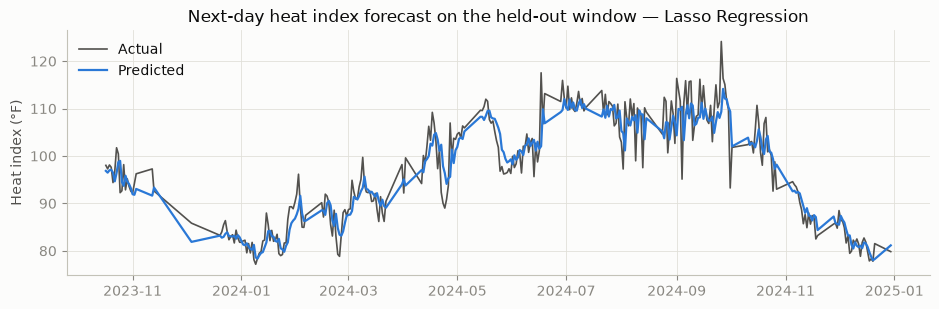

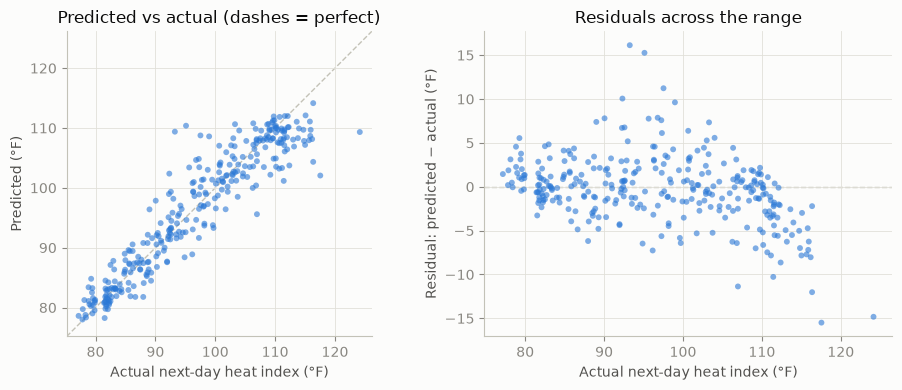

Heat-category agreement on test days: 72.9%
predicted  cool  warm  hot  very hot
actual                              
cool         94     6    0         0
warm          8    55   15         1
hot           0     8   65         9
very hot      0     0   37        12


In [7]:
import matplotlib.pyplot as plt

INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, BLUE = "#e1e0d9", "#c3c2b7", "#2a78d6"
SURFACE = "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlecolor": INK, "font.size": 10,
})

final_model = tuned[best_name]["estimator"]
final_model.fit(X_train, y_train)  # refit on the full training window
pred_test = final_model.predict(X_test)

print(f"Held-out test window: {test.index.min().date()} to {test.index.max().date()} ({len(test)} days)\n")
model_rmse = report_scores(f"{best_name} (test)", y_test, pred_test)
persist_rmse = report_scores("Persistence (test)", y_test, X_test["heat_index"])
print(f"\nForecast skill vs persistence: {1 - model_rmse / persist_rmse:+.1%} RMSE reduction")

# Forecast overlay across the test window.
fig, ax = plt.subplots(figsize=(9.5, 3.2))
ax.plot(y_test.index, y_test, color=INK2, lw=1.2, label="Actual")
ax.plot(y_test.index, pred_test, color=BLUE, lw=1.6, label="Predicted")
ax.set_ylabel("Heat index (°F)")
ax.set_title(f"Next-day heat index forecast on the held-out window — {best_name}")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

# Diagnostics: calibration (left) and where in the range the errors live (right).
residuals = pred_test - y_test
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
lims = [min(y_test.min(), pred_test.min()) - 2, max(y_test.max(), pred_test.max()) + 2]
axes[0].plot(lims, lims, color=BASELINE, lw=1, ls="--", zorder=1)
axes[0].scatter(y_test, pred_test, s=18, color=BLUE, alpha=0.6, edgecolors="none", zorder=2)
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].set_aspect("equal")
axes[0].set_xlabel("Actual next-day heat index (°F)")
axes[0].set_ylabel("Predicted (°F)")
axes[0].set_title("Predicted vs actual (dashes = perfect)")

axes[1].axhline(0, color=BASELINE, lw=1, ls="--", zorder=1)
axes[1].scatter(y_test, residuals, s=18, color=BLUE, alpha=0.6, edgecolors="none", zorder=2)
axes[1].set_xlabel("Actual next-day heat index (°F)")
axes[1].set_ylabel("Residual: predicted − actual (°F)")
axes[1].set_title("Residuals across the range")
fig.tight_layout()
plt.show()

# Heat-category labels from the forecast (the notebook's original downstream demo),
# now evaluated as a classification: how often does the forecast land in the right bin?
heat_bins = [-np.inf, 90, 100, 110, np.inf]
heat_labels = ["cool", "warm", "hot", "very hot"]
label_pred = pd.cut(pd.Series(pred_test, index=y_test.index), bins=heat_bins, labels=heat_labels, right=False)
label_true = pd.cut(y_test, bins=heat_bins, labels=heat_labels, right=False)
print(f"Heat-category agreement on test days: {(label_pred == label_true).mean():.1%}")
print(pd.crosstab(label_true, label_pred, rownames=["actual"], colnames=["predicted"]))


### 6 · What the model actually uses

Permutation importance on the held-out window: shuffle one feature at a time and measure how much the test RMSE increases. Unlike a model's built-in importances, this works identically for any model type and reflects performance on unseen data.

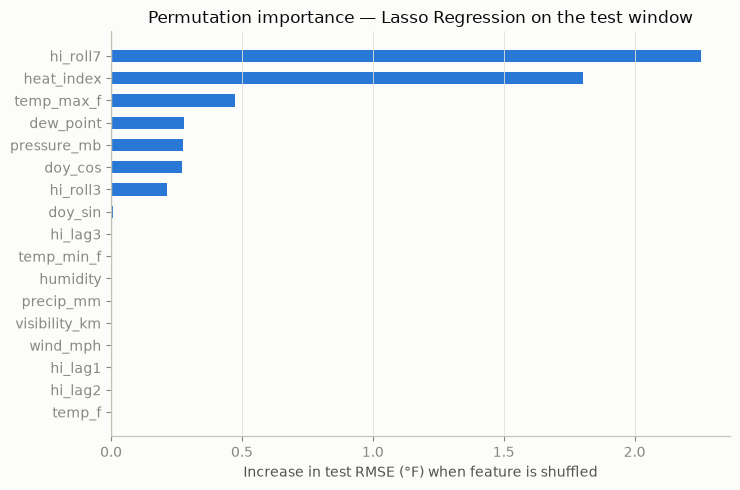

hi_roll7         2.252
heat_index       1.804
temp_max_f       0.472
dew_point        0.280
pressure_mb      0.274
doy_cos          0.271
hi_roll3         0.214
doy_sin          0.006
hi_lag3          0.001
hi_lag2          0.000
temp_min_f       0.000
humidity         0.000
precip_mm        0.000
visibility_km    0.000
wind_mph         0.000
hi_lag1          0.000
temp_f           0.000


In [8]:
# Shuffle one feature's test-window values, measure how much RMSE degrades.
# Features the model doesn't rely on (wind, most likely) land near zero.
perm = permutation_importance(final_model, X_test, y_test, n_repeats=20,
                              random_state=random_state, scoring="neg_root_mean_squared_error")
importance = pd.Series(perm.importances_mean, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh(importance.index, importance.values, color=BLUE, height=0.55)
ax.axvline(0, color=BASELINE, lw=1)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Increase in test RMSE (°F) when feature is shuffled")
ax.set_title(f"Permutation importance — {best_name} on the test window")
fig.tight_layout()
plt.show()

print(importance.sort_values(ascending=False).round(3).to_string())
